### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 50      # number of modelling nodes

In [6]:
L = 168 

In [7]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [8]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [9]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [10]:
E = 207e9
G = 79.3e9
nu=0.3

In [11]:
# integration parameters
tspan = (0., 30)

### Main functions:

In [12]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [13]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu) * (1.0 + m2)**2 + (20.0 + 12.0 * nu) * m2)

In [14]:
A2 = k_shear * A
A3 = k_shear * A

In [15]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [16]:
I2 = (np.pi / 4.0) * ((d0/2)**4 - (dI/2)**4)
I3 = I2

In [17]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [18]:
def Ret_e_t(φ,θ,ψ):
    Cφ=np.array([[1,0,0],
                  [0,np.cos(φ),-np.sin(φ)],
                  [0,np.sin(φ),np.cos(φ)]])

    Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                  [0,1,0],
                  [-np.sin(θ),0,np.cos(θ)]])

    Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                  [np.sin(ψ),np.cos(ψ),0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ

In [19]:
diag_J_t_rho = 1e2*np.array([1, 1, 2])  
J_t_rho = np.diag(diag_J_t_rho)

In [20]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT)

In [21]:
diag_CR = np.array([G*J, E*I2, E*I3])
CR=np.diag(diag_CR)

In [22]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [23]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [24]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [25]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [26]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return 1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1))

def omega_e(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return Πe(φ1,θ1,ψ1) @ d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h)

In [27]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [28]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [29]:
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2,h):
    return (Ret_e_t(φ1,θ1,ψ1)@CT@Ret_e_t(φ1,θ1,ψ1).T@(d_s_phi(x1,y1,z1,x2,y2,z2,h).reshape(3,1)
            - Ret_e_t(φ1,θ1,ψ1)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [30]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2,h):
    return Ret_e_t(φ1,θ1,ψ1)@CR@Ret_e_t(φ1,θ1,ψ1).T@ omega_e(φ1,θ1,ψ1,φ2,θ2,ψ2,h)

In [31]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [32]:
fe_g = np.array([0,0, -mp*9.81])

In [33]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [34]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [35]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [36]:
mi = [mp for i in range(N)]

In [37]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [38]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [39]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [40]:
delta_x=horizontal_length/(N-1)

In [41]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [42]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

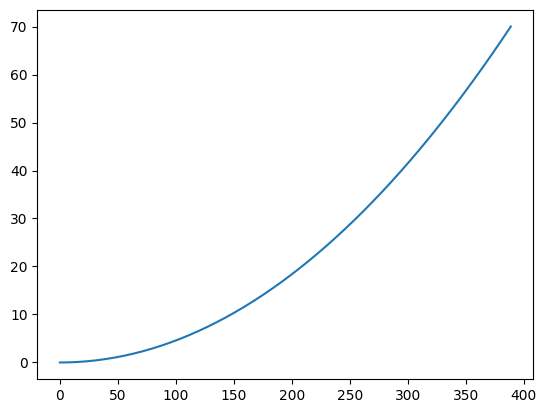

In [43]:
plt.plot(x0, z0)
plt.show()

In [44]:
q0=np.zeros(12*N)

In [45]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [46]:
h = length_p1[-1]/N

In [47]:
def fun1(x_int,φ,θ,ψ):
    
    def fun1_(x_int,φ,θ,ψ):
        A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
        B=np.zeros((3,3))
        D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(x,φ,θ,ψ) for x in x_int])
    return np.moveaxis(res, 0, -1)


def fun2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_(x, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
    
    def fun3_(x_int,φ,θ,ψ, dφ, dθ, dψ):
        A=np.zeros(3)
        B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_(x,φ,θ,ψ, dφ, dθ, dψ) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
    
    def fun4_(x_int,φ,θ,ψ, dφ, dθ, dψ):
        A=np.zeros(3)   
        B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_(x,φ,θ,ψ, dφ, dθ, dψ) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun5(x_int, li):
    
    def fun5_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_(x,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for x in x_int])
    return np.moveaxis(res, 0, -1)

def fun7(x_int,x,y,z):
   
    def fun7(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7(x,x,y,z) for x in x_int])
    return np.moveaxis(res, 0, -1)

In [48]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    
       
    for j in range(N):

        if j == N-1:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 0.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,0.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 0.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 0.0, n=2)[0])
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), 0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
            f7.append(np.zeros(6))
        else:    
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
        
    
    
    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f6) 
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  np.linalg.solve(f1[i], 
                                                           (-f2[i]
                                                            -f3[i]
                                                            -f4[i]
                                                            -f5[i]
                                                            -f6[i]
#                                                     -f7[i]
                                                   ).reshape(6,1))
  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [49]:
root_ = root(static_solution, q0,
             method='lm', 
            )

In [50]:
root_

 message: Number of calls to function has reached maxfev = 120200.
 success: False
  status: 5
     fun: [ 2.739e-14 -8.089e-14 ...  1.209e-04 -1.824e-06]
       x: [ 1.694e+00  9.635e+00 ...  4.089e-02  1.248e-24]
   cov_x: None
  method: lm
    nfev: 120244
    fjac: [[-1.902e+07  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.902e+07 ...  2.264e+03  0.000e+00]
           ...
           [ 0.000e+00  2.264e+03 ... -1.222e-25 -2.314e-01]
           [ 0.000e+00  0.000e+00 ...  1.071e-25 -2.926e-26]]
    ipvt: [404 402 ... 201 250]
     qtf: [-3.614e-03 -1.894e-05 ...  3.844e-15 -1.964e-15]

In [51]:
x0_, z0_=root_.x[:N], root_.x[4*N:5*N]

In [52]:
q0 = root_.x                                         # start from static solution

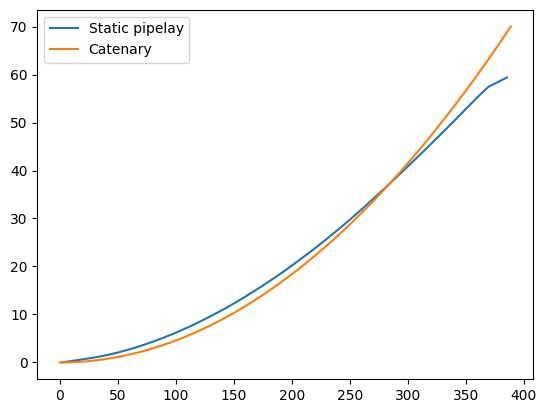

In [53]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

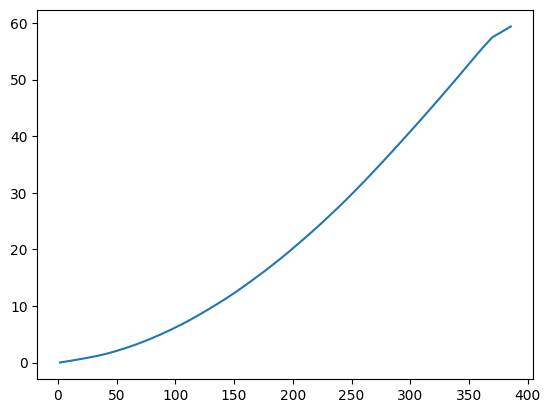

In [54]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.show()

### Vessle Simulation

In [55]:
sampleTime = 0.01              # sample time [seconds]
Number = 6000                   # number of samples

In [56]:
Number*sampleTime

60.0

In [57]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [58]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [59]:
simData.shape 

(6001, 24)

In [60]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

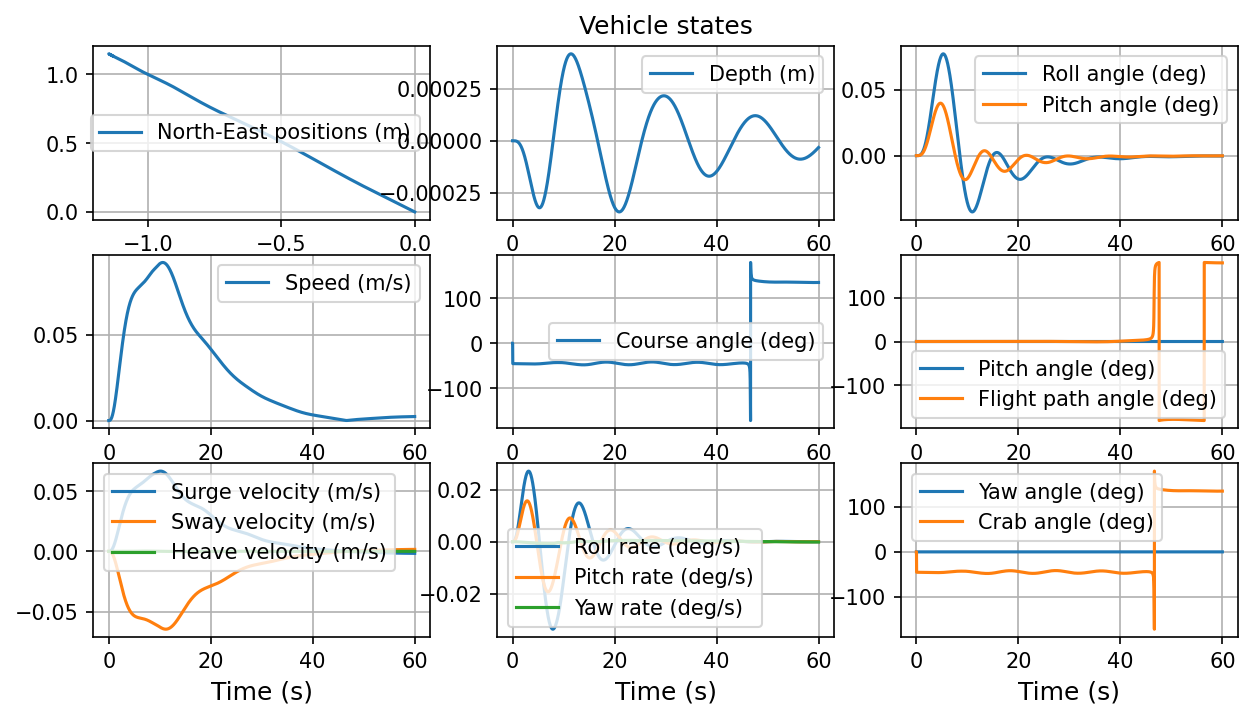

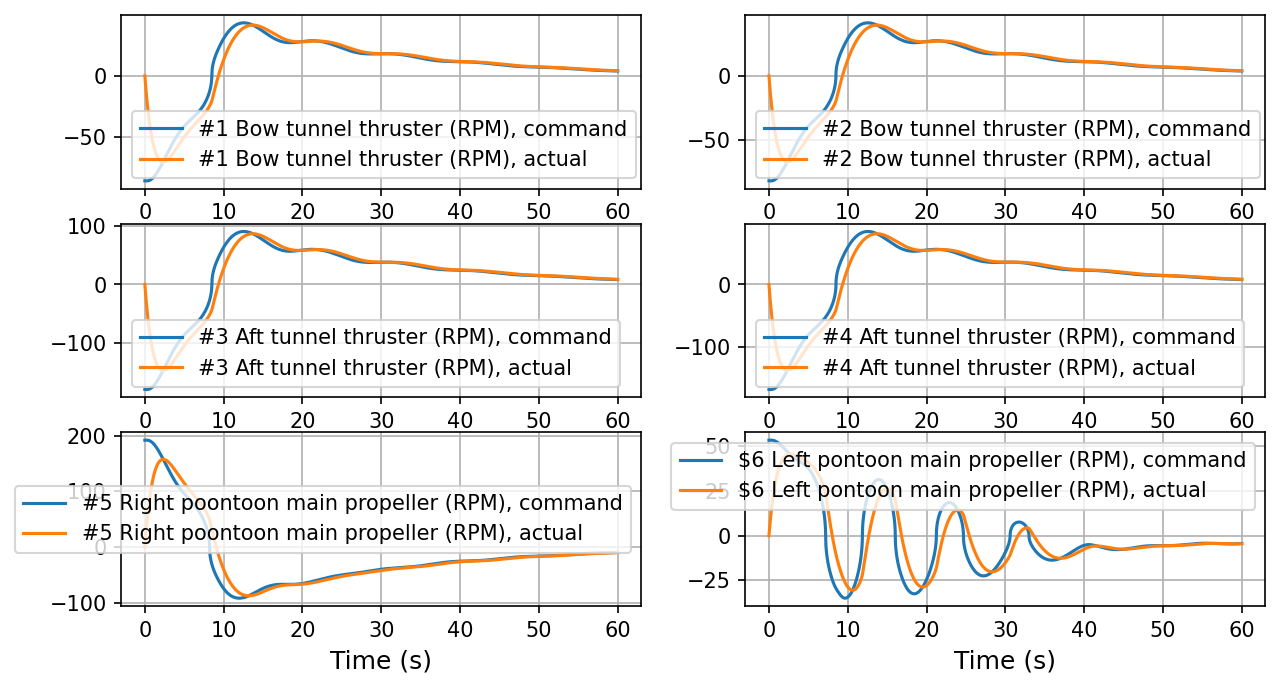

In [61]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [62]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

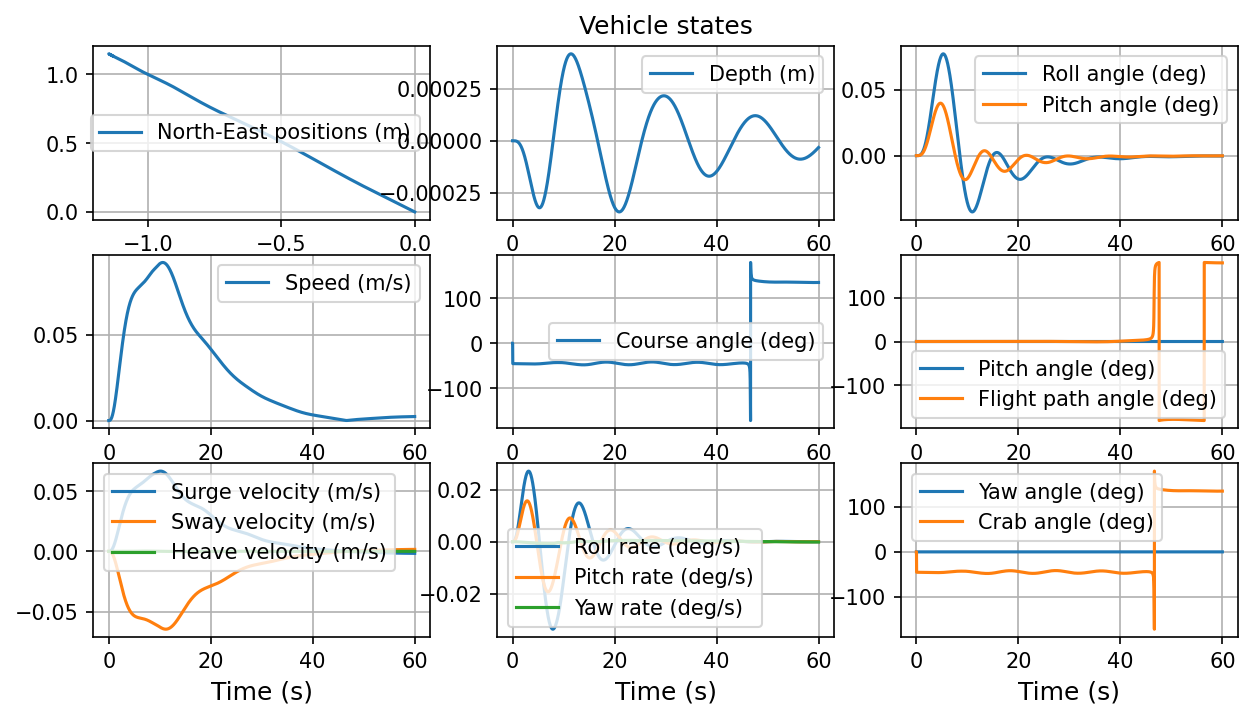

In [63]:
plotVehicleStates(simTime, simData, 3)

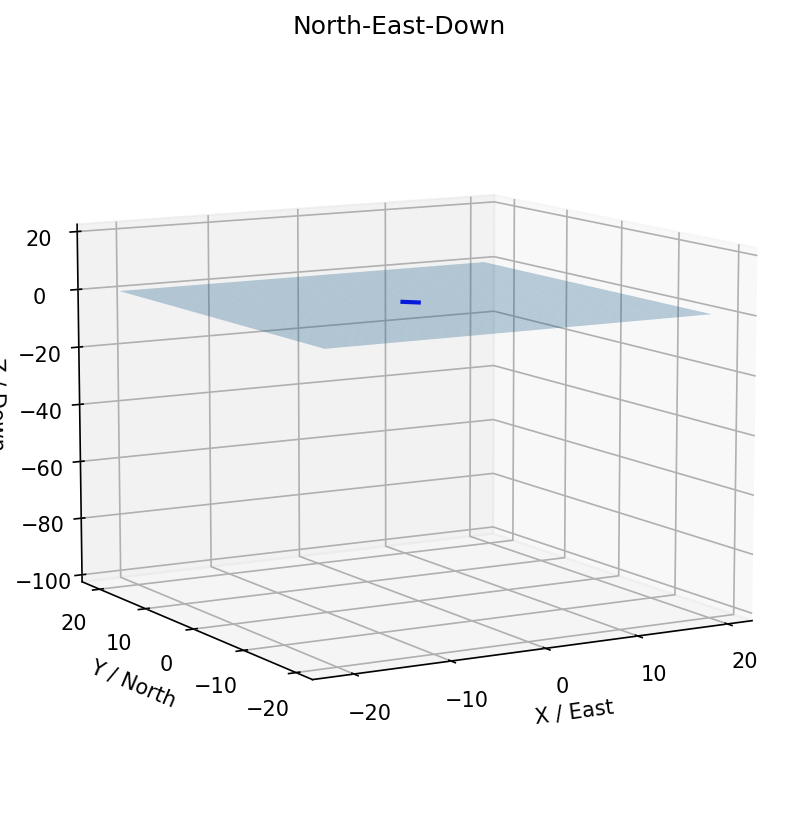

In [64]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [65]:
simData.shape

(6001, 24)

In [66]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        self.force_factor = 1
        self.L = L
        self.K = np.diag([3.5, 3.5, 25.0, 25.0, 25.0, 25.0])
        self.T1 = np.array(
            [
                [0, 0, 0, 0, 1, 1],
                [1, 1, 1, 1, 0, 0],
                [30, 20, -20, -30, -self.L / 2, self.L / 2],
            ],
            float,
        )
        self.B = self.T1 @ self.K

In [67]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 12:18], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamic Simulation

In [68]:
def dynamic_func(t, Q, T):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    
#     u_control = vessel_motion_func(t)
    u_control = np.array([0,0,np.sin(t),0,0,0])
    
    tau = T.B @ u_control
    u_actual =  T.force_factor*np.array([tau[0], tau[1], tau[2], 0 , 0, 0])
    
    
    
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
        
    for j in range(N):

        if j == N-1:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 0.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,0.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 0.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 0.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 0.0, n=2)[0])
            f8.append(u_actual)
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), 0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
            f7.append(np.zeros(6))
            f8.append(np.zeros(6))
        else:    
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j]), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))
            
        if t>0.001:
            ax=np.linalg.inv(Ret_e_t(φ[j-1],θ[j-1],ψ[j-1]))@ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j],h).T

            T.top_tension=max(T.top_tension, ax[0][0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j-1],θ[j-1],ψ[j-1])) @ me( φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j],h).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    
    
    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f6) 
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    for i in range(N):
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]), 
                                                           (
                                                            -f2[i]
                                                            -f3[i]
                                                            -f4[i]
                                                            -f5[i]
                                                            -f6[i]
#                                                     -f7[i]
                                                            +f8[i]
                                                   ).reshape(6,1))
  
    ddx=np.clip(ddx, -0.1, 0.1)
    ddy=np.clip(ddy, -0.1, 0.1)
    ddz=np.clip(ddz, -0.1, 0.1)       
    ddφ=np.clip(ddφ, -0.01, 0.01)
    ddθ=np.clip(ddθ, -0.01, 0.01)
    ddψ=np.clip(ddψ, -0.01, 0.01)
    
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 
    
    return ans

In [69]:
T_ = MyTime()

In [70]:
# initial conditions 
BC=np.zeros(N)
BC[-1] = 0.013

# q0[1*N:2*N],q0[3*N:4*N],q0[5*N:6*N]=np.zeros(N),np.zeros(N),np.zeros(N)
# q0[7*N:8*N],q0[9*N:10*N],q0[11*N:12*N]=np.zeros(N),np.zeros(N),np.zeros(N)
# q0[6*N:7*N],q0[8*N:9*N],q0[10*N:11*N]=np.zeros(N),np.zeros(N),np.zeros(N)

q0[8*N:9*N] = BC

In [71]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, 
                tspan, 
                q0, 
                args=(T_, ), 
                method='RK23'
               )
print(datetime.now() - startTime1)

Physical time:  3.7399300032953016e-06  Iteration wall-clock time:  0:00:00.060151
Physical time:  1.0082627490242395  Iteration wall-clock time:  0:00:30.932556
Physical time:  2.0048575962255812  Iteration wall-clock time:  0:00:31.713677
Physical time:  3.006240077885181  Iteration wall-clock time:  0:00:30.057682
Physical time:  4.00046185647241  Iteration wall-clock time:  0:00:22.225132
Physical time:  5.010487236383611  Iteration wall-clock time:  0:00:20.566774
Physical time:  6.000850649391397  Iteration wall-clock time:  0:00:24.976028
Physical time:  7.003093675632879  Iteration wall-clock time:  0:00:26.183354
Physical time:  8.008368108864227  Iteration wall-clock time:  0:00:24.706086
Physical time:  9.00219390738661  Iteration wall-clock time:  0:00:17.228787
Physical time:  10.008632149998009  Iteration wall-clock time:  0:00:16.577898
Physical time:  11.01618463882631  Iteration wall-clock time:  0:00:16.235073
Physical time:  12.005506237459821  Iteration wall-clock t

### Results

In [72]:
# number of iterations
T_.my_iter

15575

In [73]:
# max axial tension
T_.top_tension

6557542751.248155

In [74]:
# max bending strain
T_.sagbend_strain

13.853540717574631

In [75]:
fin=us_

In [76]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.006e-04 ...  2.999e+01  3.000e+01]
        y: [[ 1.694e+00  1.694e+00 ...  1.694e+00  1.694e+00]
            [ 9.635e+00  9.635e+00 ...  9.640e+00  9.640e+00]
            ...
            [ 4.089e-02  4.089e-02 ... -2.893e-02 -2.903e-02]
            [ 1.248e-24 -5.589e-07 ... -3.811e-02 -3.821e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 15575
     njev: 0
      nlu: 0

In [77]:
t=fin.t

In [78]:
fin=fin.y.T

In [79]:
t.shape, fin.shape

((2694,), (2694, 600))

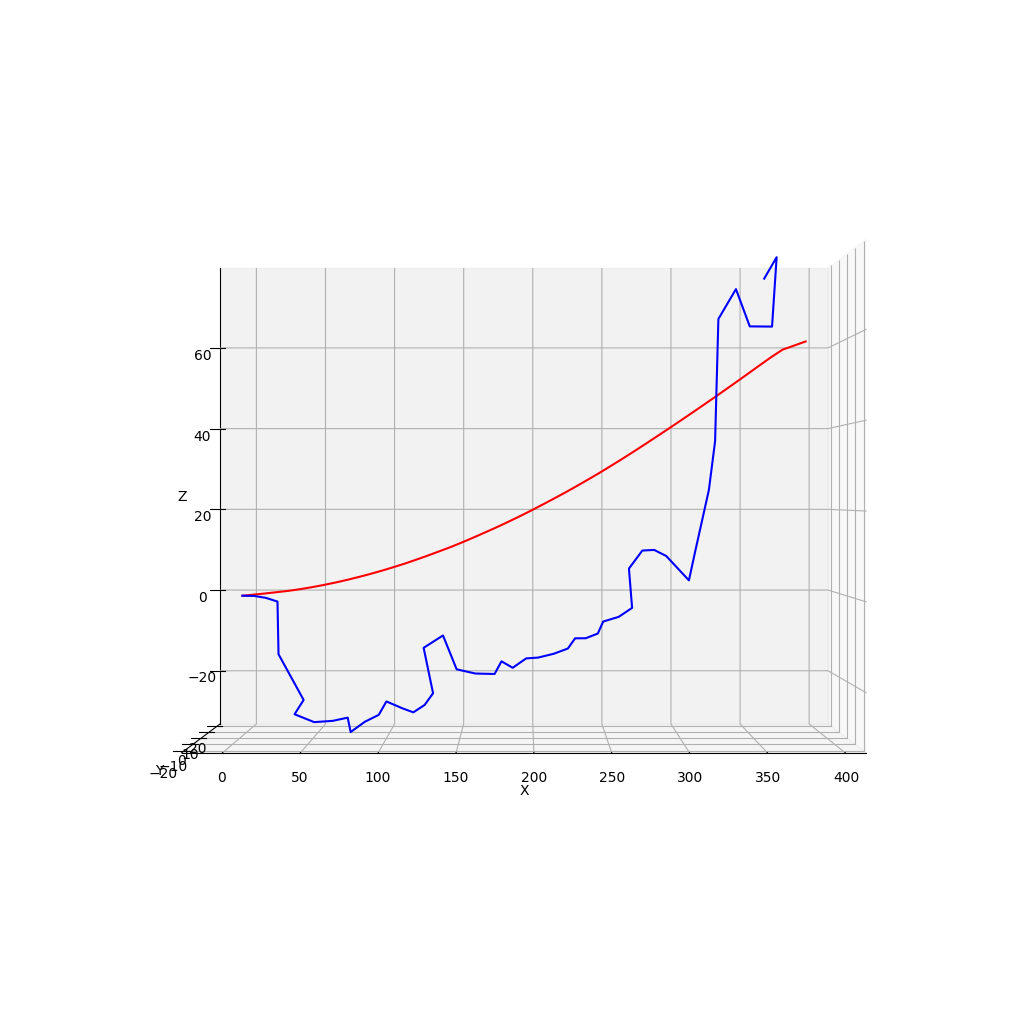

In [80]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [81]:
X,Y,Z

(array([  1.69366767,   9.63950604,  17.57700782,  25.39094217,
         21.02111913,  35.31455736,  37.82482581,  51.06904208,
         62.37748461,  73.02903434,  77.34897721,  85.31820156,
         93.6545358 , 100.62216724, 111.75594986, 117.3770821 ,
        125.77827109, 132.29387981, 125.86038048, 137.04342651,
        147.92975435, 160.77209648, 173.62654108, 178.70171961,
        185.89396285, 195.15791703, 203.30665721, 213.71808983,
        223.43051763, 228.99926101, 235.5585785 , 242.94077891,
        248.19224738, 259.19849297, 268.3938039 , 263.48802944,
        269.7071314 , 272.75894198, 278.85248293, 290.11431364,
        301.07563736, 310.81245058, 317.80300472, 325.2761077 ,
        324.841405  , 339.44907626, 343.97616602, 354.25823366,
        361.24642612, 355.5441358 ]),
 array([-2.11615751e-04, -9.37827687e-05,  8.55523668e-02,  5.34668307e-01,
         1.26705766e+01,  2.16019013e+01, -1.46430285e+00, -1.27872543e+00,
         2.78756605e+00,  1.48714778e+00, 

In [82]:
X0,Y0,Z0

(array([  1.69366767,   9.63540658,  17.57651208,  25.51693822,
         33.45663386,  41.39320301,  49.32599612,  57.25543971,
         65.18158047,  73.10345561,  81.02112476,  88.93482647,
         96.84380003, 104.74774931, 112.64736169, 120.53897247,
        128.42704917, 136.30994356, 144.19046978, 152.05959213,
        159.92191286, 167.77908722, 175.63308343, 183.47727794,
        191.31790618, 199.14777656, 206.97055879, 214.78873203,
        222.6031022 , 230.40385968, 238.20082763, 245.99012536,
        253.76711719, 261.53998394, 269.30278894, 277.05894322,
        284.81089528, 292.55881508, 300.30267452, 308.04244726,
        315.77810811, 323.50963241, 331.23699537, 338.96017136,
        346.67914628, 354.39434244, 362.11675376, 369.8677911 ,
        377.75694335, 385.64388457]),
 array([-2.11615749e-04, -1.40753982e-04, -6.99523512e-05,  7.44552317e-07,
         6.43514604e-05, -1.73836896e-05,  1.22515095e-04,  1.86863381e-04,
         1.87305103e-04,  1.33164714e-04, 

In [83]:
us=fin.T

In [84]:
us.shape

(600, 2694)

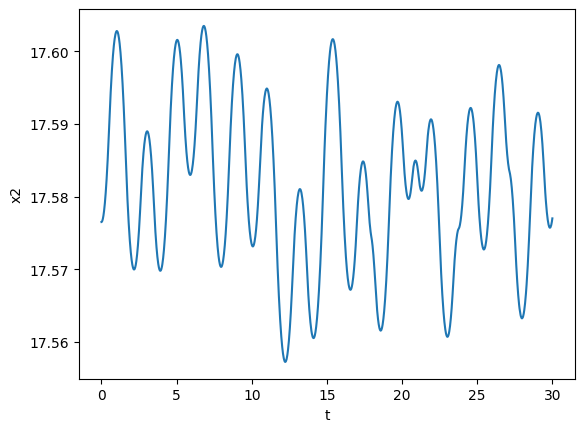

In [85]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

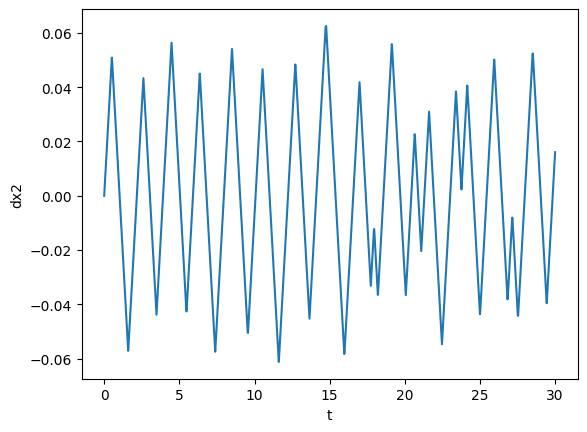

In [86]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

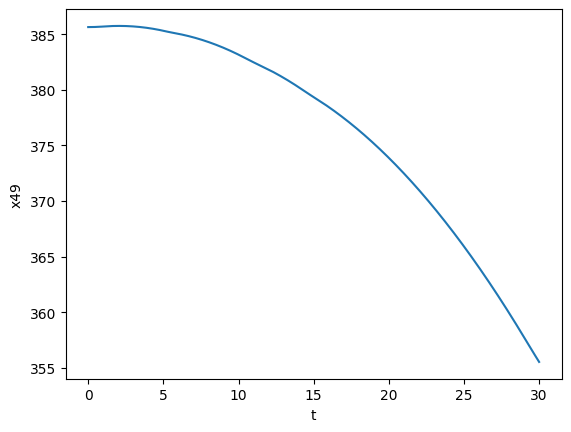

In [87]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

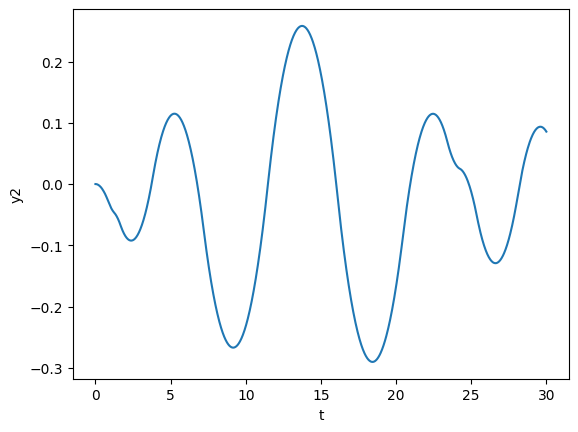

In [88]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

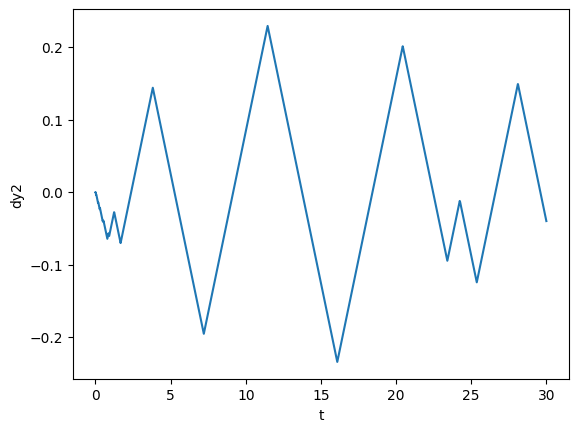

In [89]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

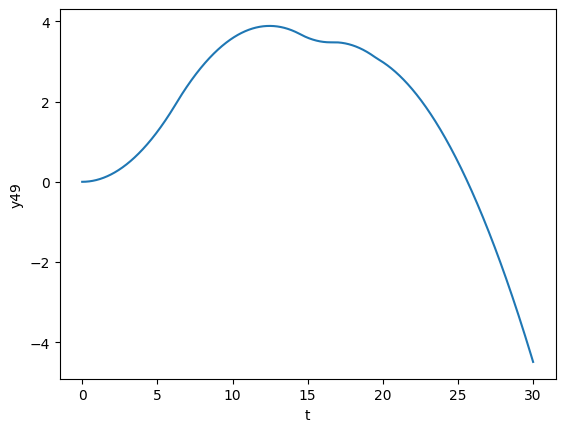

In [90]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

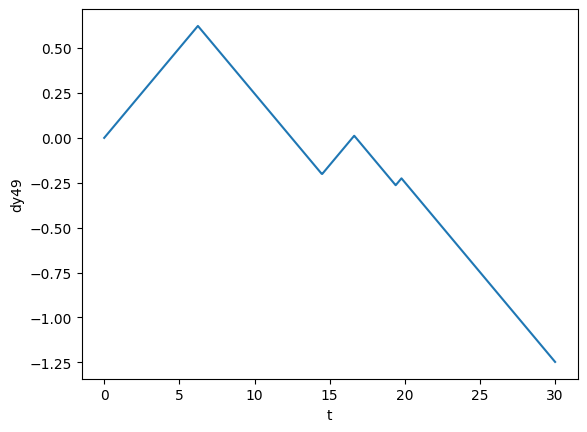

In [91]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

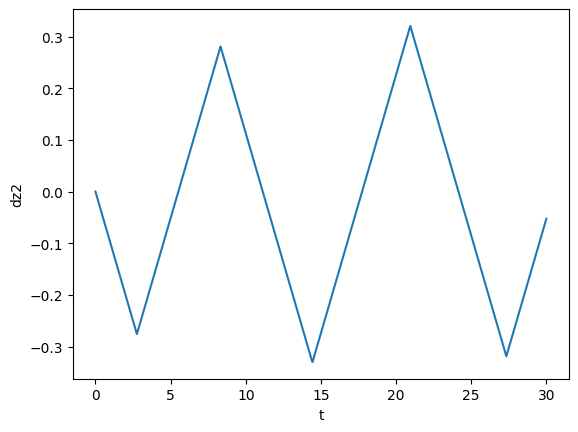

In [92]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

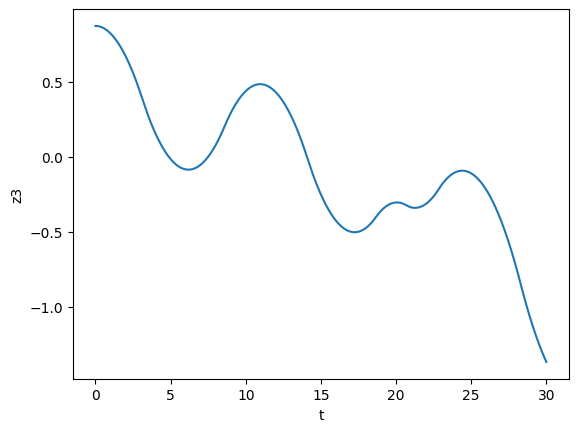

In [93]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

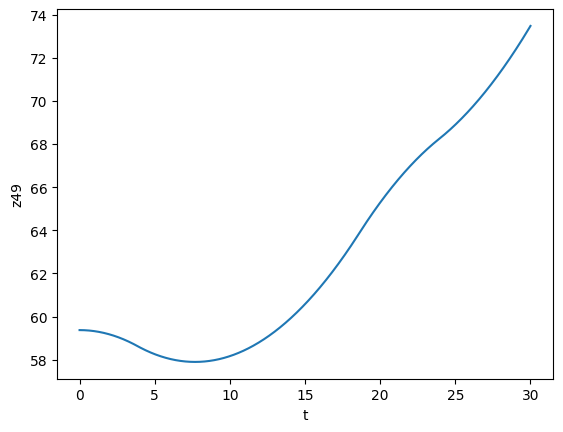

In [94]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

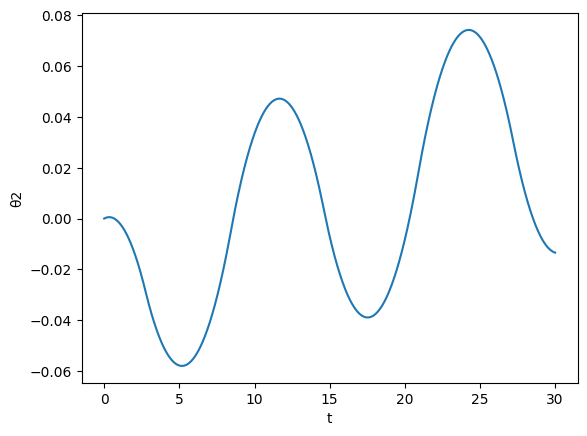

In [95]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

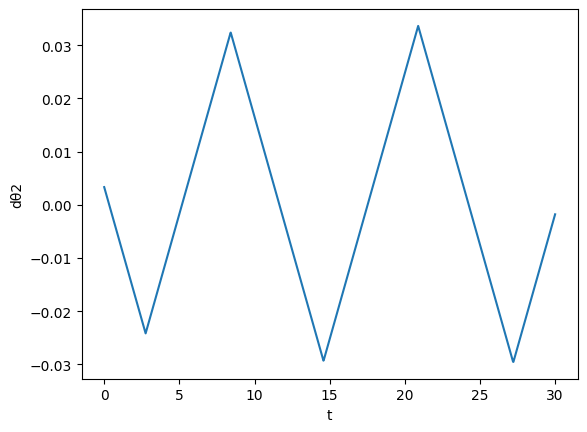

In [96]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

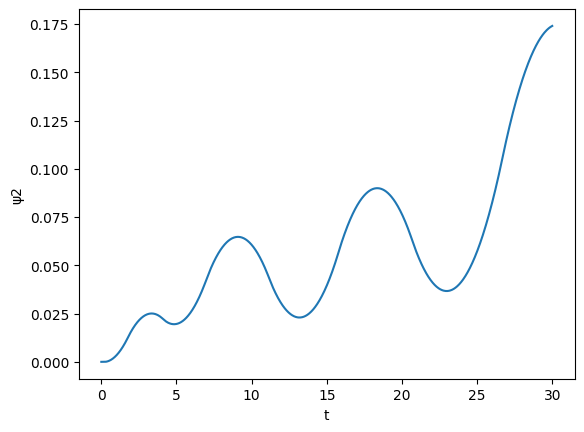

In [97]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

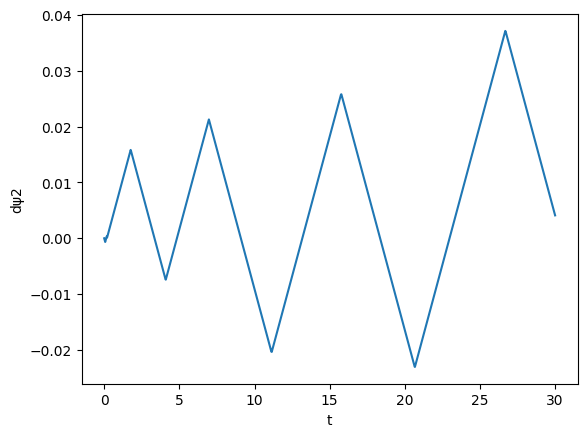

In [98]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

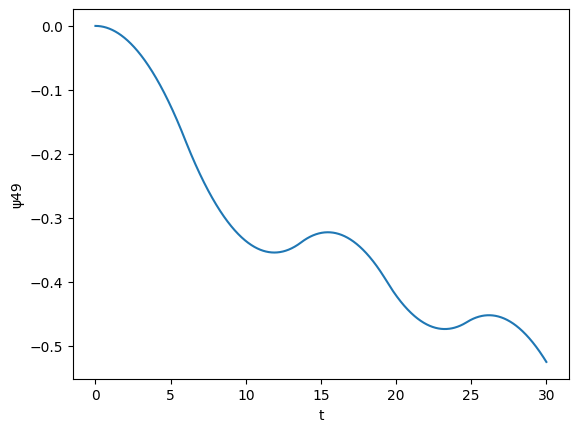

In [99]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [100]:
X010=us.T[:,0*N:1*N]

In [101]:
Y010=us.T[:,2*N:3*N]

In [102]:
Z010=us.T[:,4*N:5*N]

In [103]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()